In [18]:
import numpy as np

def numerical_jacobian(g, y): # estimates the derivatve matrix
    y = np.array(y, dtype=float) # crates array
    n = len(y)
    J = np.zeros((n, n)) # creates zero array based on size y
    eps = 1e-6 # epsillon accuracy

    for j in range(n): 
        y_forward = y.copy()
        y_backward = y.copy()

        y_forward[j] += eps
        y_backward[j] -= eps
        
        # the next line is a difference approximation
        J[:, j] = (g(y_forward) - g(y_backward)) / (2 * eps)

    return J

In [19]:
# this function solves g(y) = 0. finds the enxt value that makes the euler eqn true
def damped_newton(g, y_guess, nr_tol=1e-8, max_nr_iter=20, alpha_min=1e-4):
    y = np.array(y_guess, dtype=float)
    
    total_backtracks = 0 # tracking performance variables
    damping_needed = False # damping set to False
    final_alpha = 1.0 # final damping value
    function_evals = 0 # how many times the funtion was evaluated

    for i in range(max_nr_iter): # try to run up to max_nr_iter times
        g_val = g(y)
        function_evals += 1 # loop counter

        if np.linalg.norm(g_val) < nr_tol: # measures size of residual vector
            # if smaller, the method worked
            return y, True, i + 1, total_backtracks, final_alpha, damping_needed, function_evals

        J = numerical_jacobian(g, y) # approximates derivative

        try:
            delta = np.linalg.solve(J, -g_val) # system delta
        except:
            return y, False, i + 1, total_backtracks, final_alpha, damping_needed, function_evals

        alpha = 1.0 # damping starts here
        old_residual = np.linalg.norm(g_val)

        while alpha >= alpha_min: # if the residual is smaller,
            y_trial = y + alpha * delta
            g_trial = g(y_trial)
            function_evals += 1

            new_residual = np.linalg.norm(g_trial)

            if new_residual < old_residual:
                break

            alpha = alpha / 2 # cut the step in half
            total_backtracks += 1
            damping_needed = True

        if alpha < alpha_min:
            return y, False, i + 1, total_backtracks, alpha, damping_needed, function_evals

        y = y + alpha * delta
        final_alpha = alpha

        if np.linalg.norm(alpha * delta) < nr_tol:
            return y, True, i + 1, total_backtracks, final_alpha, damping_needed, function_evals

    return y, False, max_nr_iter, total_backtracks, final_alpha, damping_needed, function_evals

In [20]:
# takes one backward euler step. can be called multiple times
def backward_euler_step(f, t_n, y_n, h, nr_tol=1e-8, max_nr_iter=20):
    y_n = np.array(y_n, dtype=float)
    t_next = t_n + h # stores current value and computes the next value

    # Explicit Euler predictor for first guess
    y_guess = y_n + h * np.array(f(t_n, y_n), dtype=float)

    def g(y_next):
        return y_next - y_n - h * np.array(f(t_next, y_next), dtype=float)
    # measure how a badly guessed euler relates
    y_next, converged, nr_iters, backtracks, final_alpha, damping_needed, function_evals = damped_newton(
        g, y_guess, nr_tol, max_nr_iter
    )

    info = {
        'converged': converged,
        'nr_iters': nr_iters,
        'backtracks': backtracks,
        'final_alpha': final_alpha,
        'damping_needed': damping_needed,
        'function_evals': function_evals
    }
    # puts the information of steps into dictionary 
    return y_next, info

In [21]:
# this is the full solver. matches from t0 to tfinal
def adaptive_implicit_euler(f, y0, t0, t_final, h0, tol,
                            h_min=1e-6, h_max=1.0, safety=0.9,
                            nr_tol=1e-8, max_nr_iter=20):
    """
    Adaptive Euler's Backward with damped Newton-Raphson
    """
    
    # Initialize
    t = [t0]
    y = [np.array(y0, dtype=float)]
    h = h0
    h_history = []
    error_history = []
    
    stats = {
        'accepted_steps': 0,
        'rejected_steps': 0,
        'nr_iterations': [],
        'damping_used': 0,
        'function_evals': 0,
        'backtracking_steps': [],
        'final_alphas': []
    }
    
    # Main loop
    while t[-1] < t_final:
        if t[-1] + h > t_final:
            h = t_final - t[-1]

        t_n = t[-1]
        y_n = y[-1]

        # 1. Take one full step of size h
        y_full, info_full = backward_euler_step(
            f, t_n, y_n, h, nr_tol, max_nr_iter
        )

        stats['function_evals'] += info_full['function_evals']

        # If Newton-Raphson fails, reduce h and retry
        if not info_full['converged']:
            h = max(h_min, h / 2)
            stats['rejected_steps'] += 1

            if h <= h_min:
                print("Step size reached h_min and Newton-Raphson still failed.")
                break

            continue

        # 2. Take first half-step of size h/2
        y_half_1, info_half_1 = backward_euler_step(
            f, t_n, y_n, h / 2, nr_tol, max_nr_iter
        )

        stats['function_evals'] += info_half_1['function_evals']

        if not info_half_1['converged']:
            h = max(h_min, h / 2)
            stats['rejected_steps'] += 1
            continue

        # 3. Take second half-step of size h/2
        y_half_2, info_half_2 = backward_euler_step(
            f, t_n + h / 2, y_half_1, h / 2, nr_tol, max_nr_iter
        )

        stats['function_evals'] += info_half_2['function_evals']

        if not info_half_2['converged']:
            h = max(h_min, h / 2)
            stats['rejected_steps'] += 1
            continue

        # 4. Estimate local error
        err = np.linalg.norm(y_half_2 - y_full)

        # 5. Compute new step size
        eps = 1e-10
        h_new = h * np.sqrt(tol / (err + eps))

        # 6. Apply safety factor and bounds
        h_new = safety * h_new
        h_new = max(h_min, min(h_max, h_new))

        # 7. Accept or reject step
        if err < tol:
            t.append(t_n + h)
            y.append(y_half_2)
            h_history.append(h)
            error_history.append(err)

            stats['accepted_steps'] += 1

            total_iters = info_full['nr_iters'] + info_half_1['nr_iters'] + info_half_2['nr_iters']
            stats['nr_iterations'].append(total_iters)

            total_backtracks = info_full['backtracks'] + info_half_1['backtracks'] + info_half_2['backtracks']
            stats['backtracking_steps'].append(total_backtracks)

            stats['final_alphas'].append(info_full['final_alpha'])

            if info_full['damping_needed'] or info_half_1['damping_needed'] or info_half_2['damping_needed']:
                stats['damping_used'] += 1

            h = h_new

        else:
            stats['rejected_steps'] += 1
            h = h_new

            if h <= h_min:
                print("Step rejected, but h reached h_min.")
                break
    
    return np.array(t), np.array(y), h_history, error_history, stats

In [22]:
def basic_newton(g, y_guess, nr_tol=1e-8, max_nr_iter=20):
    y = np.array(y_guess, dtype=float)
    function_evals = 0

    for i in range(max_nr_iter):
        g_val = g(y)
        function_evals += 1

        if np.linalg.norm(g_val) < nr_tol:
            return y, True, i + 1, function_evals

        J = numerical_jacobian(g, y)

        try:
            delta = np.linalg.solve(J, -g_val)
        except:
            return y, False, i + 1, function_evals

        # Full Newton step only, no damping
        y = y + delta

        if np.linalg.norm(delta) < nr_tol:
            return y, True, i + 1, function_evals

    return y, False, max_nr_iter, function_evals


def backward_euler_step_basic_NR(f, t_n, y_n, h, nr_tol=1e-8, max_nr_iter=20):
    y_n = np.array(y_n, dtype=float)
    t_next = t_n + h

    # Explicit Euler predictor
    y_guess = y_n + h * np.array(f(t_n, y_n), dtype=float)

    def g(y_next):
        return y_next - y_n - h * np.array(f(t_next, y_next), dtype=float)

    y_next, converged, nr_iters, function_evals = basic_newton(
        g, y_guess, nr_tol, max_nr_iter
    )

    return y_next, converged, nr_iters, function_evals


# Problem where undamped NR may fail or struggle
h_large = 2.0

print("Testing undamped NR with h = 2.0:")

try:
    y_undamped, success_undamped, iters_undamped, evals_undamped = backward_euler_step_basic_NR(
        f, t0, y0, h_large, nr_tol=1e-8, max_nr_iter=20
    )

    print("Converged:", success_undamped)
    print("Iterations:", iters_undamped)
    print("Function evaluations:", evals_undamped)
    print("Result:", y_undamped)

except:
    print("Failed to converge!")


print("\nTesting damped NR with h = 2.0:")

y_damped, info_damped = backward_euler_step(
    f, t0, y0, h_large, nr_tol=1e-8, max_nr_iter=20
)

print("Converged:", info_damped['converged'])
print("Iterations:", info_damped['nr_iters'])
print("Function evaluations:", info_damped['function_evals'])
print("Backtracking steps:", info_damped['backtracks'])
print("Final alpha:", info_damped['final_alpha'])
print("Damping needed:", info_damped['damping_needed'])
print("Result:", y_damped)

Testing undamped NR with h = 2.0:
Converged: True
Iterations: 3
Function evaluations: 3
Result: [9.9950e-05 4.9975e-05]

Testing damped NR with h = 2.0:
Converged: True
Iterations: 3
Function evaluations: 5
Backtracking steps: 0
Final alpha: 1.0
Damping needed: False
Result: [9.9950e-05 4.9975e-05]


In [23]:
def euler_backward_fixed(f, y0, t0, t_final, h, nr_tol=1e-8, max_nr_iter=20):
    t = [t0]
    y = [np.array(y0, dtype=float)]

    stats_fixed = {
        'steps': 0,
        'nr_iterations': [],
        'function_evals': 0,
        'damping_used': 0,
        'backtracking_steps': []
    }

    while t[-1] < t_final:
        if t[-1] + h > t_final:
            h_step = t_final - t[-1]
        else:
            h_step = h

        y_next, info = backward_euler_step(
            f, t[-1], y[-1], h_step, nr_tol, max_nr_iter
        )

        stats_fixed['function_evals'] += info['function_evals']

        if not info['converged']:
            print("Fixed-step Backward Euler failed to converge.")
            break

        t.append(t[-1] + h_step)
        y.append(y_next)

        stats_fixed['steps'] += 1
        stats_fixed['nr_iterations'].append(info['nr_iters'])
        stats_fixed['backtracking_steps'].append(info['backtracks'])

        if info['damping_needed']:
            stats_fixed['damping_used'] += 1

    return np.array(t), np.array(y), stats_fixed

In [24]:
# Fixed step size baseline
t_fixed, y_fixed, stats_fixed = euler_backward_fixed(
    f, y0, t0, t_final, h=0.01, nr_tol=1e-8, max_nr_iter=20
)

# Adaptive step size solver
tol = 1e-4

t_adapt, y_adapt, h_hist, error_history, stats = adaptive_implicit_euler(
    f, y0, t0, t_final, h0=0.1, tol=tol,
    h_min=1e-6,
    h_max=1.0,
    safety=0.9,
    nr_tol=1e-8,
    max_nr_iter=20
)

print("\nPerformance Comparison:")
print(f"{'Method':<25} {'Steps':<10} {'Func Evals':<15} {'Avg NR Iters':<15} {'Damping Used':<15}")
print("-" * 85)

print(f"{'Fixed BE (h=0.01)':<25} "
      f"{stats_fixed['steps']:<10} "
      f"{stats_fixed['function_evals']:<15} "
      f"{np.mean(stats_fixed['nr_iterations']):<15.2f} "
      f"{stats_fixed['damping_used']:<15}")

print(f"{'Adaptive BE':<25} "
      f"{stats['accepted_steps']:<10} "
      f"{stats['function_evals']:<15} "
      f"{np.mean(stats['nr_iterations']):<15.2f} "
      f"{stats['damping_used']:<15}")

print("\nAdaptive Step Details:")
print("Accepted steps:", stats['accepted_steps'])
print("Rejected steps:", stats['rejected_steps'])
print("Minimum h:", np.min(h_hist))
print("Maximum h:", np.max(h_hist))
print("Average h:", np.mean(h_hist))
print("Maximum error estimate:", np.max(error_history))


Performance Comparison:
Method                    Steps      Func Evals      Avg NR Iters    Damping Used   
-------------------------------------------------------------------------------------
Fixed BE (h=0.01)         5          15              2.00            0              
Adaptive BE               60         630             6.00            0              

Adaptive Step Details:
Accepted steps: 60
Rejected steps: 10
Minimum h: 5.7169430427514954e-05
Maximum h: 0.0185737670054614
Average h: 0.0008333333333333334
Maximum error estimate: 9.204701577760762e-05


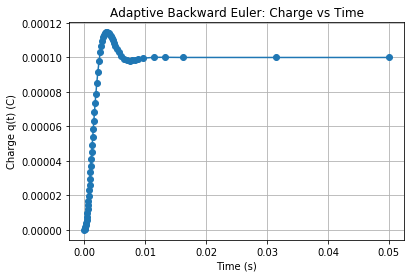

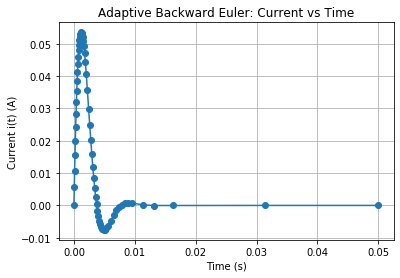

In [27]:
import matplotlib.pyplot as plt
# graph the charge v time
plt.figure()
plt.plot(t_adapt, y_adapt[:, 0], marker='o')
plt.xlabel("Time (s)")
plt.ylabel("Charge q(t) (C)")
plt.title("Adaptive Backward Euler: Charge vs Time")
plt.grid(True)
plt.show()
# graph current v time
plt.figure()
plt.plot(t_adapt, y_adapt[:, 1], marker='o')
plt.xlabel("Time (s)")
plt.ylabel("Current i(t) (A)")
plt.title("Adaptive Backward Euler: Current vs Time")
plt.grid(True)
plt.show()


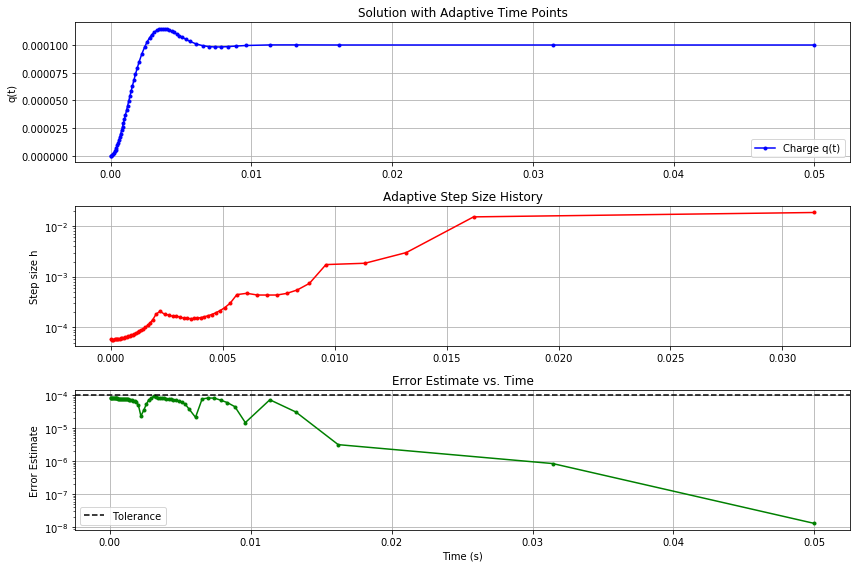

In [26]:
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(t_adapt, y_adapt[:, 0], 'b-o', markersize=3, label='Charge q(t)')
plt.ylabel('q(t)')
plt.title('Solution with Adaptive Time Points')
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 2)
plt.semilogy(t_adapt[:-1], h_hist, 'r-o', markersize=3)
plt.ylabel('Step size h')
plt.title('Adaptive Step Size History')
plt.grid(True)

plt.subplot(3, 1, 3)
plt.semilogy(t_adapt[1:], error_history, 'g-o', markersize=3)
plt.axhline(y=tol, color='k', linestyle='--', label='Tolerance')
plt.ylabel('Error Estimate')
plt.xlabel('Time (s)')
plt.title('Error Estimate vs. Time')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()